In [ ]:
import os
import re
import json
import time
import random
import zlib 
from collections import Counter
from datetime import datetime
import numpy as np
import requests
from datasets import load_dataset 
from rank_bm25 import BM25Okapi 
import matplotlib.pyplot as plt
from pathlib import Path


RUN_ROOT = os.path.join(os.getcwd(), "runs_fixed_pool_rerank")
os.makedirs(RUN_ROOT, exist_ok=True)

def utc_stamp():
    return datetime.utcnow().strftime("%Y%m%d_%H%M%S")

def ensure_dir(p):
    os.makedirs(p, exist_ok=True)
    return p

def write_json(path, obj):
    # for congigs and metadata
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def write_jsonl(path, rows):
    # for logs and long lists
    with open(path, "w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")


In [ ]:
# not the official multi-news dataset from github repo
# community based parquet version on huggingface
# original repo links were broken
DATASET_ID = "Awesome075/multi_news_parquet"

N_TARGET = None # optional cap on number of documents to process
                # we used only during development

MIN_SOURCES = 8 # 9 or 10 are sparse sources

DOC_MIN_CHARS = 80 # filter out very short documents if any
DOC_TRUNC_CHARS = 2000 # later truncated further with QUERY_TRUNC_CHARS
QUERY_MAX_CHARS = 400

GLOBAL_SEED = 1337
COUNT_KS = [8, 9, 10] # later used for reporting data availability
                      # recorind data availability on larger k values

KEEP_LIST = [3, 4, 5, 6] # number of documents to keep after reranking
                         # paper reports 3, and 5 as representative

PROGRESS_EVERY = 10 # for logging

DOC_VIEW_CHARS = 600 # final snppet view length
QUERY_TRUNC_CHARS = 400 # QUERY_MAX_CHARS used the same, no effective trunc.

MMR_LAMBDA_EXP1 = 0.7 # default, not tuned
MMR_LAMBDAS = [MMR_LAMBDA_EXP1]

RANDOM_SEED = 2026
LLM_ORDER_SEED_BASE = 0

def norm_ws(s):
    return re.sub(r"\s+", " ", (s or "")).strip()

def split_sources(document_field):
    # as documented from multi-news repo
    parts = (document_field or "").split("|||||")
    out = []
    for p in parts:
        t = norm_ws(p)
        if t:
            out.append(t)
    return out

def first_sentence(text):
    text = norm_ws(text)
    if not text:
        return ""
    parts = re.split(r"(?<=[\.\!\?])\s+", text)
    if parts and parts[0].strip():
        return parts[0].strip()
    return text[:QUERY_MAX_CHARS]

def view_doc(d, n=DOC_VIEW_CHARS):
    return norm_ws(d)[:n]


In [3]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
STOPWORDS = set(ENGLISH_STOP_WORDS)

def tok_raw(s):
    return re.findall(r"[a-z0-9]+", (s or "").lower())

def tok_content(s):
    toks = re.findall(r"[a-z0-9]+", (s or "").lower())
    out = []
    for t in toks:
        if t in STOPWORDS:
            continue
        if t.isdigit():
            continue
        out.append(t)
    return out

def jaccard_set(a, b):
    a = set(a)
    b = set(b)
    if not a and not b:
        return 1.0
    return len(a & b) / max(1, len(a | b))

def kendall_tau(rank_a, rank_b):
    pos_a = {item: i for i, item in enumerate(rank_a)}
    pos_b = {item: i for i, item in enumerate(rank_b)}
    items = list(pos_a.keys())

    concordant = 0
    discordant = 0
    n = len(items)

    for i in range(n):
        for j in range(i + 1, n):
            x = items[i]
            y = items[j]
            da = pos_a[x] - pos_a[y]
            db = pos_b[x] - pos_b[y]
            if da == 0 or db == 0:
                continue
            if (da > 0 and db > 0) or (da < 0 and db < 0):
                concordant += 1
            else:
                discordant += 1

    denom = concordant + discordant
    if denom == 0:
        return 0.0
    return (concordant - discordant) / denom

def metrics_bundle(query, summary, docs):
    q_raw = set(tok_raw(query))
    q_cont = set(tok_content(query))

    union_raw = set()
    union_cont = set()
    doc_terms_cont = []

    for d in docs:
        tr = set(tok_raw(d))
        tc = set(tok_content(d))
        union_raw |= tr
        union_cont |= tc
        doc_terms_cont.append(tc)

    cov_raw = len(union_raw & q_raw) / max(1, len(q_raw)) if q_raw else 0.0
    cov_cont = len(union_cont & q_cont) / max(1, len(q_cont)) if q_cont else 0.0

    sims = []
    for i in range(len(doc_terms_cont)):
        for j in range(i + 1, len(doc_terms_cont)):
            a = doc_terms_cont[i]
            b = doc_terms_cont[j]
            sims.append(len(a & b) / max(1, len(a | b)))
    red_cont = sum(sims) / len(sims) if sims else 0.0

    ref = set(tok_content(summary))
    sum_rec = len(union_cont & ref) / max(1, len(ref)) if ref else 0.0

    return {
        "cov_raw": float(cov_raw),
        "cov_cont": float(cov_cont),
        "red_cont": float(red_cont),
        "sum_rec": float(sum_rec),
    }

def bm25_rank_within(query, candidates):
    corpus = [tok_content(d) for d in candidates]
    bm25 = BM25Okapi(corpus)
    scores = bm25.get_scores(tok_content(query))
    return sorted(range(len(scores)), key=lambda x: scores[x], reverse=True)

def jaccard_text_content(a, b):
    a = set(tok_content(a))
    b = set(tok_content(b))
    return len(a & b) / max(1, len(a | b)) if (a or b) else 0.0

def mmr_rank_within_bm25rel(query, candidates, lam):
    corpus = [tok_content(d) for d in candidates]
    bm25 = BM25Okapi(corpus)
    rel_scores = bm25.get_scores(tok_content(query))

    selected = []
    remaining = list(range(len(candidates)))

    while remaining:
        best_ix = None
        best_score = None
        for ix in remaining:
            r = float(rel_scores[ix])
            div = 0.0
            if selected:
                div = max(jaccard_text_content(candidates[ix], candidates[j]) for j in selected)
            score = lam * r - (1.0 - lam) * div
            if best_score is None or score > best_score:
                best_score = score
                best_ix = ix
        selected.append(best_ix)
        remaining.remove(best_ix)

    return selected

def random_rank_within(example_idx, candidates_len=8, seed=2026):
    rng = random.Random(seed + int(example_idx))
    order = list(range(candidates_len))
    rng.shuffle(order)
    return order

def extract_json_obj(text):
    s = (text or "").strip()
    if not s:
        return None
    try:
        return json.loads(s)
    except Exception:
        pass
    i = s.find("{")
    j = s.rfind("}")
    if i >= 0 and j > i:
        chunk = s[i:j+1]
        try:
            return json.loads(chunk)
        except Exception:
            return None
    return None

def clamp_indices(arr, k):
    if not isinstance(arr, list):
        return None
    out = []
    seen = set()
    for x in arr:
        try:
            ix = int(x)
        except Exception:
            continue
        if 0 <= ix < k and ix not in seen:
            seen.add(ix)
            out.append(ix)
    return out if out else None

def build_candidates_block(docs):
    parts = []
    for i, d in enumerate(docs):
        parts.append(f"[{i}] {norm_ws(d)}")
    return "\n".join(parts)

LLM_PROMPT_REL_ONLY = """You are ranking evidence documents for a query.

Task:
- You are given exactly 8 candidate documents.
- Rank ALL 8 documents from best to worst.

Ranking goal:
1) Relevance to the query.

Return ONLY strict JSON with exactly 8 unique indices:
{"ranked_indices":[...]}"""


## Prepare Dataset

In [ ]:
splits = ["train", "validation", "test"]

# preliminary pass to collect eligible references
# and dataset statistics
totals_by_split = Counter()
raw_exact = Counter()
full_exact = Counter()
raw_ge = Counter()
full_ge = Counter()

eligible_refs = []

for split_name in splits:
    ds = load_dataset(DATASET_ID, split=split_name)
    totals_by_split[split_name] = len(ds)

    for i, row in enumerate(ds):
        document_field = row["document"] if not isinstance(row, dict) else row.get("document", "")
        sources_all = split_sources(document_field)

        raw_count = len(sources_all)
        sources_full = [s for s in sources_all if len(s) >= DOC_MIN_CHARS]
        full_count = len(sources_full)

        raw_exact[raw_count] += 1
        full_exact[full_count] += 1

        if full_count >= MIN_SOURCES:
            eligible_refs.append((split_name, i))

        # for data exploration only
        for k in COUNT_KS:
            if raw_count >= k:
                raw_ge[k] += 1
            if full_count >= k:
                full_ge[k] += 1

print("Dataset totals by split", dict(totals_by_split))
print("Eligible clusters with >= 8 usable sources", len(eligible_refs))

rng = random.Random(GLOBAL_SEED)
rng.shuffle(eligible_refs)

picked_refs = eligible_refs if N_TARGET is None else eligible_refs[:min(N_TARGET, len(eligible_refs))]


# we build and store a frozen record for reproducibility
ds_cache = {}
prep_rows = []

for split_name, example_id in picked_refs:
    if split_name not in ds_cache:
        ds_cache[split_name] = load_dataset(DATASET_ID, split=split_name)

    ds = ds_cache[split_name]
    row = ds[example_id]

    document_field = row["document"]
    summary_field = row["summary"]

    sources_all = split_sources(document_field)
    raw_count = len(sources_all)

    sources_full = [s for s in sources_all if len(s) >= DOC_MIN_CHARS]
    full_count = len(sources_full)

    split_hash = zlib.crc32(split_name.encode("utf-8"))
    seed = GLOBAL_SEED + split_hash + int(example_id) # final seed is stored in prep_rows
    rr = random.Random(seed)

    candidates_8 = rr.sample(sources_full, k=MIN_SOURCES)
    candidates_8 = [norm_ws(c)[:DOC_TRUNC_CHARS] for c in candidates_8]

    query = first_sentence(summary_field)

    prep_rows.append({
        "split": split_name,
        "example_id": int(example_id),
        "query": query,
        "summary": norm_ws(summary_field),
        "candidates_8": candidates_8,
        "all_sources_count_raw": int(raw_count),
        "all_sources_count_full": int(full_count),
        "sampling_seed": int(seed),
    })

print(f"Prepared {len(prep_rows)} examples with exactly {MIN_SOURCES} usable candidates each.")

prep_dir = ensure_dir(os.path.join(RUN_ROOT, "prep_" + utc_stamp()))
write_json(os.path.join(prep_dir, "prep_meta.json"), {
    "dataset_id": DATASET_ID,
    "n_target": N_TARGET,
    "min_sources": MIN_SOURCES,
    "doc_min_chars": DOC_MIN_CHARS,
    "doc_trunc_chars": DOC_TRUNC_CHARS,
    "query_max_chars": QUERY_MAX_CHARS,
    "global_seed": GLOBAL_SEED,
    "n_examples": len(prep_rows),
})
write_jsonl(os.path.join(prep_dir, "prep_rows.jsonl"), prep_rows)

print("Saved frozen prep to", prep_dir)


Dataset totals by split {'train': 44972, 'validation': 5622, 'test': 5622}
Eligible clusters with >= 8 usable sources 345
Prepared 345 examples with exactly 8 usable candidates each.
Saved frozen prep to /home/baris/projects/submitted_multinews_llm_ranking_public-Revised/runs_fixed_pool_rerank/prep_20260412_183048


/tmp/ipykernel_429189/2187023.py:20: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().strftime("%Y%m%d_%H%M%S")


In [ ]:
def run_one_model(prep_rows, run_tag, model_kind, model_name, call_llm_fn, retries, extra_meta):
    results_by_keep = {k: [] for k in KEEP_LIST}
    rank_rows = []

    llm_fallbacks = 0
    llm_calls = 0

    call_logs = [] 

    for idx, ex in enumerate(prep_rows):
        query = ex["query"]
        summary = ex.get("summary", "")

        candidates = [view_doc(c) for c in ex["candidates_8"]]
        if len(candidates) != 8:
            continue

        rank_bm25 = bm25_rank_within(query, candidates)
        rank_mmr = mmr_rank_within_bm25rel(query, candidates, lam=MMR_LAMBDA_EXP1)
        rank_rand = random_rank_within(idx, candidates_len=8, seed=RANDOM_SEED)

        k = len(candidates)
        perm = list(range(k))
        order_seed = int(LLM_ORDER_SEED_BASE) + int(idx)
        rng = random.Random(int(order_seed))
        rng.shuffle(perm)

        docs_perm = [candidates[i] for i in perm]
        prompt = (
            LLM_PROMPT_REL_ONLY
            + "\n\nQUERY:\n" + query
            + "\n\nCANDIDATE DOCUMENTS:\n" + build_candidates_block(docs_perm)
            + "\n\nReturn JSON only."
        )

        calls = 0
        fail = 1
        raw_text = ""
        parsed_obj = None
        rank_llm = None

        for _ in range(int(retries) + 1):
            raw_text = call_llm_fn(prompt)
            calls += 1

            parsed_obj = extract_json_obj(raw_text)
            if parsed_obj and "ranked_indices" in parsed_obj:
                ranked = clamp_indices(parsed_obj["ranked_indices"], k)
                if ranked and len(ranked) == k:
                    rank_llm = [perm[i] for i in ranked]
                    fail = 0
                    break

            time.sleep(0.25)

        llm_calls += calls

        if fail or rank_llm is None:
            llm_fallbacks += 1
            rank_llm = rank_bm25

        call_logs.append({
            "idx": int(idx),
            "split": ex.get("split", ""),
            "example_id": int(ex.get("example_id", -1)),
            "order_seed": int(order_seed),
            "model_kind": model_kind,
            "model_name": model_name,
            "prompt": prompt,
            "raw_response": raw_text,
            "parsed_obj": parsed_obj,
            "fail": int(fail),
            "calls": int(calls),
            "rank_llm_used": list(rank_llm),
        })

        rank_rows.append({
            "idx": idx,
            "split": ex.get("split", ""),
            "example_id": ex.get("example_id", -1),
            "order_seed": int(order_seed),
            "rank_bm25": list(rank_bm25),
            "rank_mmr": list(rank_mmr),
            "rank_llm": list(rank_llm),
            "rank_rand": list(rank_rand),
            "tau_llm_bm25": kendall_tau(rank_llm, rank_bm25),
            "tau_llm_mmr": kendall_tau(rank_llm, rank_mmr),
            "tau_llm_rand": kendall_tau(rank_llm, rank_rand),
        })

        for keep in KEEP_LIST:
            top_bm25 = rank_bm25[:keep]
            top_mmr = rank_mmr[:keep]
            top_llm = rank_llm[:keep]
            top_rand = rank_rand[:keep]

            docs_bm25 = [candidates[i] for i in top_bm25]
            docs_mmr = [candidates[i] for i in top_mmr]
            docs_llm = [candidates[i] for i in top_llm]
            docs_rand = [candidates[i] for i in top_rand]

            m_bm25 = metrics_bundle(query, summary, docs_bm25)
            m_mmr = metrics_bundle(query, summary, docs_mmr)
            m_llm = metrics_bundle(query, summary, docs_llm)
            m_rand = metrics_bundle(query, summary, docs_rand)

            results_by_keep[keep].append({
                "idx": idx,
                "split": ex.get("split", ""),
                "example_id": ex.get("example_id", -1),

                "bm25_cov_raw": m_bm25["cov_raw"],
                "bm25_cov_cont": m_bm25["cov_cont"],
                "bm25_red_cont": m_bm25["red_cont"],
                "bm25_sum_rec": m_bm25["sum_rec"],

                "mmr_cov_raw": m_mmr["cov_raw"],
                "mmr_cov_cont": m_mmr["cov_cont"],
                "mmr_red_cont": m_mmr["red_cont"],
                "mmr_sum_rec": m_mmr["sum_rec"],

                "llm_cov_raw": m_llm["cov_raw"],
                "llm_cov_cont": m_llm["cov_cont"],
                "llm_red_cont": m_llm["red_cont"],
                "llm_sum_rec": m_llm["sum_rec"],

                "rand_cov_raw": m_rand["cov_raw"],
                "rand_cov_cont": m_rand["cov_cont"],
                "rand_red_cont": m_rand["red_cont"],
                "rand_sum_rec": m_rand["sum_rec"],

                "bm25_topk": list(top_bm25),
                "mmr_topk": list(top_mmr),
                "llm_topk": list(top_llm),
                "rand_topk": list(top_rand),

                "jacc_llm_bm25": jaccard_set(top_llm, top_bm25),
                "jacc_llm_mmr": jaccard_set(top_llm, top_mmr),
                "jacc_llm_rand": jaccard_set(top_llm, top_rand),
            })

        if (idx + 1) % PROGRESS_EVERY == 0:
            print(f"{idx+1}/{len(prep_rows)} done | llm_fallbacks={llm_fallbacks}")

    meta = {
        "run_tag": run_tag,
        "model_kind": model_kind,
        "model_name": model_name,
        "n_examples_used": len(rank_rows),
        "keep_list": list(KEEP_LIST),
        "mmr_lambda_exp1": float(MMR_LAMBDA_EXP1),
        "doc_view_chars": int(DOC_VIEW_CHARS),
        "query_trunc_chars": int(QUERY_TRUNC_CHARS),
        "random_seed": int(RANDOM_SEED),
        "llm_order_seed_base": int(LLM_ORDER_SEED_BASE),
        "llm_fallback_rate": llm_fallbacks / max(1, len(rank_rows)),
        "llm_avg_calls": llm_calls / max(1, len(rank_rows)),
    }

    for k, v in (extra_meta or {}).items():
        meta[k] = v

    run_dir = ensure_dir(os.path.join(RUN_ROOT, f"{run_tag}_{extra_meta['run_name']}_{utc_stamp()}"))

    write_json(os.path.join(run_dir, "meta.json"), meta)
    write_jsonl(os.path.join(run_dir, "rank_rows.jsonl"), rank_rows)
    write_jsonl(os.path.join(run_dir, "call_logs.jsonl"), call_logs)

    flat_results = []
    for kk in sorted(results_by_keep.keys()):
        for r in results_by_keep[kk]:
            rr = dict(r)
            rr["keep"] = int(kk)
            flat_results.append(rr)
    write_jsonl(os.path.join(run_dir, "results_by_keep_flat.jsonl"), flat_results)

    print("Saved run to", run_dir)
    print("Meta", meta)

    return results_by_keep, rank_rows, meta, run_dir


### Ollama Run

In [12]:
OLLAMA_URL = "http://localhost:11434/api/generate"
LLAMA_MODEL = "llama3.1:8b-instruct-q4_K_M"
LLAMA_TEMPERATURE = 0.0
LLAMA_NUM_PREDICT = 80
LLAMA_RETRIES = 2

def llama_call(prompt):
    payload = {
        "model": LLAMA_MODEL,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": float(LLAMA_TEMPERATURE), "num_predict": int(LLAMA_NUM_PREDICT)},
    }
    r = requests.post(OLLAMA_URL, json=payload, timeout=240)
    r.raise_for_status()
    return (r.json().get("response", "") or "").strip()

results_llama, rank_llama, meta_llama, run_dir_llama = run_one_model(
    prep_rows=prep_rows,
    run_tag="exp1",
    model_kind="ollama",
    model_name=LLAMA_MODEL,
    call_llm_fn=llama_call,
    retries=LLAMA_RETRIES,
    extra_meta={
        "run_name": "llama",
        "ollama_url": OLLAMA_URL,
        "ollama_temperature": float(LLAMA_TEMPERATURE),
        "ollama_num_predict": int(LLAMA_NUM_PREDICT),
    },
)


10/345 done | llm_fallbacks=0
20/345 done | llm_fallbacks=0
30/345 done | llm_fallbacks=0
40/345 done | llm_fallbacks=0
50/345 done | llm_fallbacks=0
60/345 done | llm_fallbacks=0
70/345 done | llm_fallbacks=0
80/345 done | llm_fallbacks=0
90/345 done | llm_fallbacks=0
100/345 done | llm_fallbacks=0
110/345 done | llm_fallbacks=0
120/345 done | llm_fallbacks=0
130/345 done | llm_fallbacks=0
140/345 done | llm_fallbacks=0
150/345 done | llm_fallbacks=0
160/345 done | llm_fallbacks=0
170/345 done | llm_fallbacks=0
180/345 done | llm_fallbacks=0
190/345 done | llm_fallbacks=0
200/345 done | llm_fallbacks=0
210/345 done | llm_fallbacks=0
220/345 done | llm_fallbacks=0
230/345 done | llm_fallbacks=0
240/345 done | llm_fallbacks=0
250/345 done | llm_fallbacks=0
260/345 done | llm_fallbacks=0
270/345 done | llm_fallbacks=0
280/345 done | llm_fallbacks=0
290/345 done | llm_fallbacks=0
300/345 done | llm_fallbacks=0
310/345 done | llm_fallbacks=0
320/345 done | llm_fallbacks=0
330/345 done | ll

C:\Users\aratb\AppData\Local\Temp\ipykernel_44296\3941481114.py:20: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().strftime("%Y%m%d_%H%M%S")


### Qwen Run

In [13]:
OLLAMA_URL = "http://localhost:11434/api/generate"
QWEN_MODEL = "qwen2.5:7b-instruct-q4_K_M"
QWEN_TEMPERATURE = 0.0
QWEN_NUM_PREDICT = 80
QWEN_RETRIES = 2

def qwen_call(prompt):
    payload = {
        "model": QWEN_MODEL,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": float(QWEN_TEMPERATURE), "num_predict": int(QWEN_NUM_PREDICT)},
    }
    r = requests.post(OLLAMA_URL, json=payload, timeout=240)
    r.raise_for_status()
    return (r.json().get("response", "") or "").strip()


results_qwen, rank_qwen, meta_qwen, run_dir_qwen = run_one_model(
    prep_rows=prep_rows,
    run_tag="exp1",
    model_kind="ollama",
    model_name=QWEN_MODEL,
    call_llm_fn=qwen_call,
    retries=QWEN_RETRIES,
    extra_meta={
        "run_name": "qwen",
        "model_name_full": QWEN_MODEL,
        "ollama_temperature": QWEN_TEMPERATURE,
        "ollama_num_predict": QWEN_NUM_PREDICT,
    },
)


10/345 done | llm_fallbacks=0
20/345 done | llm_fallbacks=0
30/345 done | llm_fallbacks=0
40/345 done | llm_fallbacks=0
50/345 done | llm_fallbacks=0
60/345 done | llm_fallbacks=0
70/345 done | llm_fallbacks=0
80/345 done | llm_fallbacks=0
90/345 done | llm_fallbacks=0
100/345 done | llm_fallbacks=0
110/345 done | llm_fallbacks=0
120/345 done | llm_fallbacks=0
130/345 done | llm_fallbacks=0
140/345 done | llm_fallbacks=0
150/345 done | llm_fallbacks=0
160/345 done | llm_fallbacks=0
170/345 done | llm_fallbacks=0
180/345 done | llm_fallbacks=0
190/345 done | llm_fallbacks=0
200/345 done | llm_fallbacks=0
210/345 done | llm_fallbacks=0
220/345 done | llm_fallbacks=0
230/345 done | llm_fallbacks=0
240/345 done | llm_fallbacks=0
250/345 done | llm_fallbacks=0
260/345 done | llm_fallbacks=0
270/345 done | llm_fallbacks=0
280/345 done | llm_fallbacks=0
290/345 done | llm_fallbacks=0
300/345 done | llm_fallbacks=0
310/345 done | llm_fallbacks=0
320/345 done | llm_fallbacks=0
330/345 done | ll

C:\Users\aratb\AppData\Local\Temp\ipykernel_44296\3941481114.py:20: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().strftime("%Y%m%d_%H%M%S")


In [ ]:
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "").strip()

openai_client = OpenAI(api_key=OPENAI_API_KEY)

GPT_MODEL = "gpt-5-mini"
GPT_RETRIES = 2
OPENAI_TIMEOUT_SECONDS = 240
# we used a higher max token than other models here
# as the lower parameters resulted in frequent failures
OPENAI_MAX_TOKENS = 2000
# also temperature param is not allowed in the current version of api
# thus, we rely on the default parameters
# reproduced results may differ slightly due to this
# we tested re-runs and found small digit variations, not affecting overall trends

def gpt_call(prompt):
    resp = openai_client.chat.completions.create(
        model=GPT_MODEL,
        messages=[
            {"role": "system", "content": "Return only JSON."},
            {"role": "user", "content": prompt},
        ],
        response_format={"type": "json_object"},
        max_completion_tokens=int(OPENAI_MAX_TOKENS),
        timeout=OPENAI_TIMEOUT_SECONDS,
    )
    return (resp.choices[0].message.content or "").strip()

results_gpt, rank_gpt, meta_gpt, run_dir_gpt = run_one_model(
    prep_rows=prep_rows,
    run_tag="exp1",
    model_kind="openai",
    model_name=GPT_MODEL,
    call_llm_fn=gpt_call,
    retries=GPT_RETRIES,
    extra_meta={
        "run_name": "gpt",
        "model_name_full": GPT_MODEL,
        "openai_json_mode": True,
        "openai_max_completion_tokens": OPENAI_MAX_TOKENS,
    },
)


10/345 done | llm_fallbacks=0
20/345 done | llm_fallbacks=0
30/345 done | llm_fallbacks=0
40/345 done | llm_fallbacks=0
50/345 done | llm_fallbacks=0
60/345 done | llm_fallbacks=0
70/345 done | llm_fallbacks=0
80/345 done | llm_fallbacks=0
90/345 done | llm_fallbacks=0
100/345 done | llm_fallbacks=0
110/345 done | llm_fallbacks=0
120/345 done | llm_fallbacks=0
130/345 done | llm_fallbacks=0
140/345 done | llm_fallbacks=0
150/345 done | llm_fallbacks=0
160/345 done | llm_fallbacks=0
170/345 done | llm_fallbacks=0
180/345 done | llm_fallbacks=0
190/345 done | llm_fallbacks=0
200/345 done | llm_fallbacks=0
210/345 done | llm_fallbacks=0
220/345 done | llm_fallbacks=0
230/345 done | llm_fallbacks=0
240/345 done | llm_fallbacks=0
250/345 done | llm_fallbacks=0
260/345 done | llm_fallbacks=0
270/345 done | llm_fallbacks=0
280/345 done | llm_fallbacks=0
290/345 done | llm_fallbacks=0
300/345 done | llm_fallbacks=0
310/345 done | llm_fallbacks=0
320/345 done | llm_fallbacks=0
330/345 done | ll

C:\Users\aratb\AppData\Local\Temp\ipykernel_44296\3941481114.py:20: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().strftime("%Y%m%d_%H%M%S")


In [ ]:
def mean(rows, key):
    return sum(r[key] for r in rows) / len(rows) if rows else 0.0

def summarize(results_by_keep, rank_rows, meta):
    out = {"meta": meta, "by_keep": {}, "rank_corr": {}}

    out["rank_corr"] = {
        "tau_llm_bm25": mean(rank_rows, "tau_llm_bm25"),
        "tau_llm_mmr": mean(rank_rows, "tau_llm_mmr"),
        "tau_llm_rand": mean(rank_rows, "tau_llm_rand"),
    }

    def agg(rows, prefix):
        return {
            "cov_raw": mean(rows, f"{prefix}_cov_raw"),
            "cov_cont": mean(rows, f"{prefix}_cov_cont"),
            "red_cont": mean(rows, f"{prefix}_red_cont"),
            "sum_rec": mean(rows, f"{prefix}_sum_rec"),
        }

    for keep, rows in results_by_keep.items():
        out["by_keep"][keep] = {
            "bm25": agg(rows, "bm25"),
            "mmr": agg(rows, "mmr"),
            "llm": agg(rows, "llm"),
            "rand": agg(rows, "rand"),
            "agreement": {
                "jacc_llm_bm25": mean(rows, "jacc_llm_bm25"),
                "jacc_llm_mmr": mean(rows, "jacc_llm_mmr"),
                "jacc_llm_rand": mean(rows, "jacc_llm_rand"),
            },
        }

    return out

def plot_frontier(summary, use_content=True):
    # plot coverage vs redundancy frontier
    # for eda, we used during development only
    ks = sorted(KEEP_LIST)

    plt.figure()
    series = [("bm25", "bm25"), ("mmr", "mmr"), ("llm", "llm"), ("rand", "rand")]

    for label, key in series:
        xs = []
        ys = []
        for k in ks:
            red = summary["by_keep"][k][key]["red_cont"]
            cov = summary["by_keep"][k][key]["cov_cont"] if use_content else summary["by_keep"][k][key]["cov_raw"]
            xs.append(red)
            ys.append(cov)

        plt.plot(xs, ys, marker="o", label=label)

        for i, k in enumerate(ks):
            plt.annotate(f"K={k}", (xs[i], ys[i]), textcoords="offset points", xytext=(6, 6), fontsize=8)

    plt.title("Coverage-Redundancy Frontier")
    plt.xlabel("Redundancy lower is better")
    plt.ylabel("Coverage higher is better")
    plt.legend()
    plt.show()

def plot_agreement(summary):
    # plot agreement vs k
    # for eda, we used during development only
    plt.figure()
    xs = sorted(KEEP_LIST)
    y_bm25 = [summary["by_keep"][k]["agreement"]["jacc_llm_bm25"] for k in xs]
    y_mmr = [summary["by_keep"][k]["agreement"]["jacc_llm_mmr"] for k in xs]
    y_rand = [summary["by_keep"][k]["agreement"]["jacc_llm_rand"] for k in xs]

    plt.plot(xs, y_bm25, marker="o", label="LLM vs BM25")
    plt.plot(xs, y_mmr, marker="o", label="LLM vs MMR")
    plt.plot(xs, y_rand, marker="o", label="LLM vs Random")

    plt.title("Top-K Agreement")
    plt.xlabel("K")
    plt.ylabel("Jaccard")
    plt.xticks(xs)
    plt.legend()
    plt.show()

def save_summary(results_by_keep, rank_rows, meta, run_dir):
    s = summarize(results_by_keep, rank_rows, meta)
    write_json(os.path.join(run_dir, "summary.json"), s)

    print("Mean Kendall tau")
    print("  tau(LLM, BM25)", s["rank_corr"]["tau_llm_bm25"])
    print("  tau(LLM, MMR)", s["rank_corr"]["tau_llm_mmr"])
    print("  tau(LLM, Random)", s["rank_corr"]["tau_llm_rand"])

    plot_frontier(s, use_content=True)
    plot_agreement(s)

    return s


Mean Kendall tau
  tau(LLM, BM25) 0.19399585921325052
  tau(LLM, MMR) 0.1888198757763975
  tau(LLM, Random) 0.007453416149068324


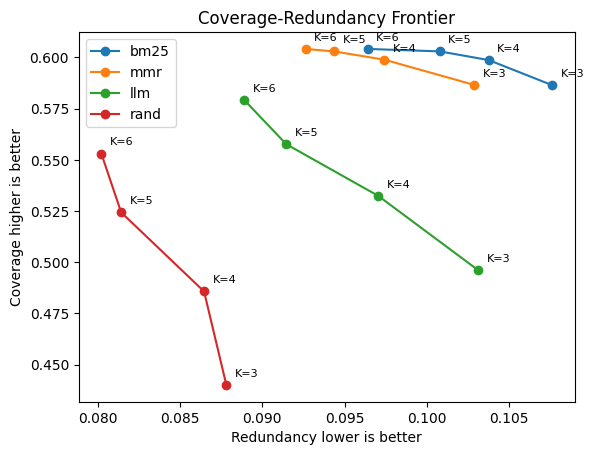

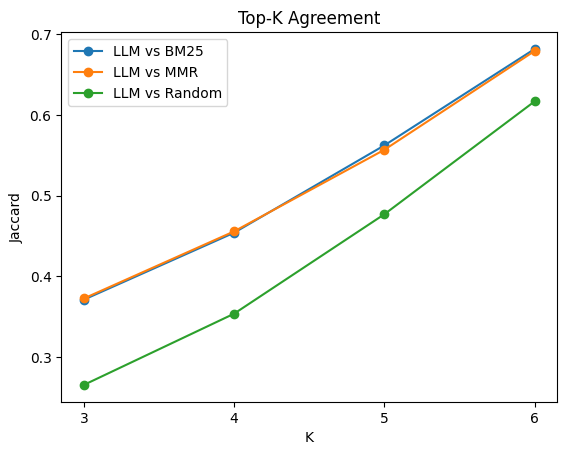

In [17]:
summary_llama = save_summary(results_llama, rank_llama, meta_llama, run_dir_llama)


Mean Kendall tau
  tau(LLM, BM25) 0.32712215320910976
  tau(LLM, MMR) 0.31573498964803315
  tau(LLM, Random) -0.017184265010351966


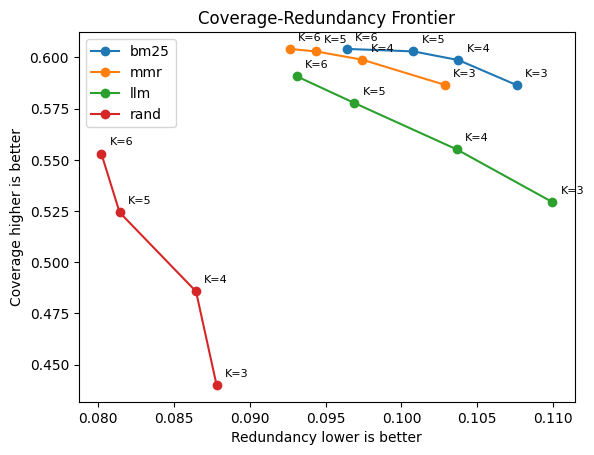

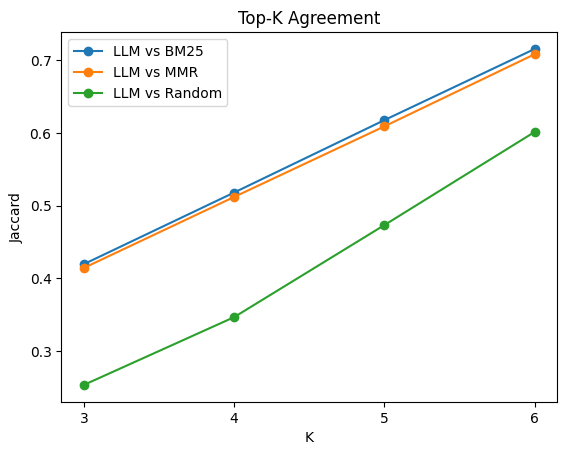

In [18]:
summary_qwen = save_summary(results_qwen, rank_qwen, meta_qwen, run_dir_qwen)


Mean Kendall tau
  tau(LLM, BM25) 0.41469979296066256
  tau(LLM, MMR) 0.39461697722567285
  tau(LLM, Random) -0.004968944099378881


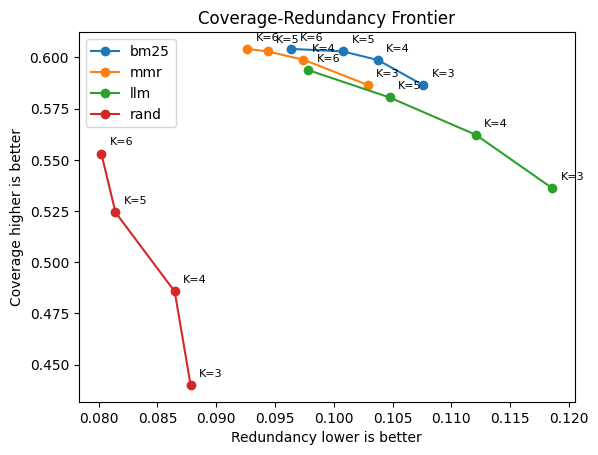

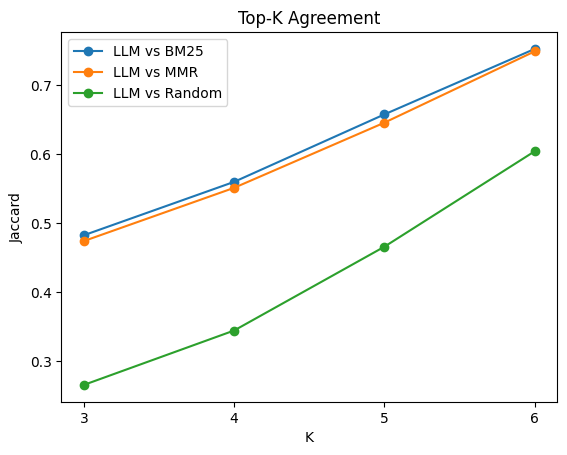

In [19]:
summary_gpt = save_summary(results_gpt, rank_gpt, meta_gpt, run_dir_gpt)


## Review of Results

In [ ]:
RUN_ROOT = Path.cwd() / "runs_fixed_pool_rerank"

RUNS = {
    "Llama": os.path.join(RUN_ROOT, "exp1_llama_20260131_140548"),
    "Qwen": os.path.join(RUN_ROOT, "exp1_qwen_20260131_143032"),
    "GPT": os.path.join(RUN_ROOT, "exp1_gpt_20260131_154255"),
}


In [23]:
def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def read_jsonl(path):
    out = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            out.append(json.loads(line))
    return out

def mean(rows, key):
    return sum(r[key] for r in rows) / len(rows) if rows else 0.0


In [24]:
def load_run(run_dir):
    meta = read_json(os.path.join(run_dir, "meta.json"))
    rank_rows = read_jsonl(os.path.join(run_dir, "rank_rows.jsonl"))
    flat = read_jsonl(os.path.join(run_dir, "results_by_keep_flat.jsonl"))
    return meta, rank_rows, flat

def agreement_stats(rank_rows, flat):
    tau_llm_bm25 = mean(rank_rows, "tau_llm_bm25")
    tau_llm_mmr = mean(rank_rows, "tau_llm_mmr")
    tau_llm_rand = mean(rank_rows, "tau_llm_rand")

    rows_k3 = [r for r in flat if int(r["keep"]) == 3]
    if not rows_k3:
        raise RuntimeError("No keep=3 rows found in results_by_keep_flat.jsonl")

    j_llm_bm25 = mean(rows_k3, "jacc_llm_bm25")
    j_llm_mmr = mean(rows_k3, "jacc_llm_mmr")
    j_llm_rand = mean(rows_k3, "jacc_llm_rand")

    return {
        "tau_llm_bm25": tau_llm_bm25,
        "tau_llm_mmr": tau_llm_mmr,
        "tau_llm_rand": tau_llm_rand,
        "jacc3_llm_bm25": j_llm_bm25,
        "jacc3_llm_mmr": j_llm_mmr,
        "jacc3_llm_rand": j_llm_rand,
    }

all_agreement = {}

for name, path in RUNS.items():
    meta, rank_rows, flat = load_run(path)
    stats = agreement_stats(rank_rows, flat)
    all_agreement[name] = {"meta": meta, "stats": stats}

    print(name)
    print("  model_name", meta.get("model_name"))
    print("  n_examples_used", meta.get("n_examples_used"))
    print("  tau llm bm25", stats["tau_llm_bm25"])
    print("  tau llm mmr", stats["tau_llm_mmr"])
    print("  tau llm rand", stats["tau_llm_rand"])
    print("  top3 jacc llm bm25", stats["jacc3_llm_bm25"])
    print("  top3 jacc llm mmr", stats["jacc3_llm_mmr"])
    print("  top3 jacc llm rand", stats["jacc3_llm_rand"])
    print()


Llama
  model_name llama3.1:8b-instruct-q4_K_M
  n_examples_used 345
  tau llm bm25 0.19399585921325052
  tau llm mmr 0.1888198757763975
  tau llm rand 0.007453416149068324
  top3 jacc llm bm25 0.37130434782608696
  top3 jacc llm mmr 0.37275362318840577
  top3 jacc llm rand 0.2657971014492754

Qwen
  model_name qwen2.5:7b-instruct-q4_K_M
  n_examples_used 345
  tau llm bm25 0.32712215320910976
  tau llm mmr 0.31573498964803315
  tau llm rand -0.017184265010351966
  top3 jacc llm bm25 0.4194202898550724
  top3 jacc llm mmr 0.4142028985507247
  top3 jacc llm rand 0.25304347826086954

GPT
  model_name gpt-5-mini
  n_examples_used 345
  tau llm bm25 0.41469979296066256
  tau llm mmr 0.39461697722567285
  tau llm rand -0.004968944099378881
  top3 jacc llm bm25 0.48202898550724643
  top3 jacc llm mmr 0.4736231884057971
  top3 jacc llm rand 0.26521739130434785



In [ ]:
METHOD_PREFIX = {
    "BM25": "bm25",
    "MMR": "mmr",
    "LLM": "llm",
    "Random": "rand",
}

COMPARISONS = [
    ("MMR", "LLM"),
    ("BM25", "LLM"),
    ("LLM", "Random"),
]

LEX_METRICS = ["cov_cont", "red_cont", "sum_rec"]

def paired_bootstrap_ci(a, b, n_boot=10000, seed=12345, alpha=0.05):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    n = len(a)
    rng = np.random.default_rng(seed)

    obs = float(np.mean(a - b)) # observed mean difference, mean delta reported
    idx = rng.integers(0, n, size=(n_boot, n)) # n_boot samples of n indices with replacement
    diffs = (a[idx] - b[idx]).mean(axis=1) # mean differences for each bootstrap sample

    lo, hi = np.quantile(diffs, [alpha / 2, 1 - alpha / 2])
    p_pos = float(np.mean(diffs > 0))
    return obs, float(lo), float(hi), p_pos

def get_metric_array(rows, method_label, metric_key):
    prefix = METHOD_PREFIX[method_label]
    col = f"{prefix}_{metric_key}"
    if col not in rows[0]:
        raise RuntimeError("Missing column " + col)
    return np.array([r[col] for r in rows], dtype=float)

def bootstrap_for_run(flat, k_focus, metrics, n_boot=10000, seed=12345):
    rows = [r for r in flat if int(r["keep"]) == int(k_focus)]
    if not rows:
        raise RuntimeError("No rows for keep " + str(k_focus))

    out = {}
    for metric_key in metrics:
        out[metric_key] = {}
        for A, B in COMPARISONS:
            a = get_metric_array(rows, A, metric_key)
            b = get_metric_array(rows, B, metric_key)
            obs, lo, hi, ppos = paired_bootstrap_ci(a, b, n_boot=n_boot, seed=seed, alpha=0.05)
            out[metric_key][f"{A}-{B}"] = {
                "mean_delta": obs,
                "lo": lo,
                "hi": hi,
                "p_pos": ppos,
            }
    return out

all_bootstrap = {}

for name, path in RUNS.items():
    meta, rank_rows, flat = load_run(path)
    boot3 = bootstrap_for_run(flat, 3, LEX_METRICS)
    boot5 = bootstrap_for_run(flat, 5, LEX_METRICS)
    all_bootstrap[name] = {"K3": boot3, "K5": boot5}

    print(name, "bootstrap done")


Llama bootstrap done
Qwen bootstrap done
GPT bootstrap done


In [28]:
def fmt_ci(mean_delta, lo, hi):
    return f"{mean_delta:+.3f} [{lo:+.3f},{hi:+.3f}]"

print()
print("Bootstrap deltas")
for name in ["Llama", "Qwen", "GPT"]:
    boot = all_bootstrap[name]
    print(name)

    for metric_key in ["cov_cont", "red_cont", "sum_rec"]:
        k3 = boot["K3"][metric_key]
        k5 = boot["K5"][metric_key]

        line = metric_key + "  " + \
            "K3 " + \
            fmt_ci(k3["MMR-LLM"]["mean_delta"], k3["MMR-LLM"]["lo"], k3["MMR-LLM"]["hi"]) + "  " + \
            fmt_ci(k3["BM25-LLM"]["mean_delta"], k3["BM25-LLM"]["lo"], k3["BM25-LLM"]["hi"]) + "  " + \
            fmt_ci(k3["LLM-Random"]["mean_delta"], k3["LLM-Random"]["lo"], k3["LLM-Random"]["hi"]) + "  " + \
            "K5 " + \
            fmt_ci(k5["MMR-LLM"]["mean_delta"], k5["MMR-LLM"]["lo"], k5["MMR-LLM"]["hi"]) + "  " + \
            fmt_ci(k5["BM25-LLM"]["mean_delta"], k5["BM25-LLM"]["lo"], k5["BM25-LLM"]["hi"]) + "  " + \
            fmt_ci(k5["LLM-Random"]["mean_delta"], k5["LLM-Random"]["lo"], k5["LLM-Random"]["hi"])

        print(line)

    print()



Bootstrap deltas
Llama
cov_cont  K3 +0.091 [+0.077,+0.106]  +0.090 [+0.076,+0.106]  +0.056 [+0.037,+0.076]  K5 +0.045 [+0.036,+0.056]  +0.045 [+0.036,+0.056]  +0.033 [+0.019,+0.047]
red_cont  K3 -0.000 [-0.009,+0.007]  +0.004 [-0.003,+0.012]  +0.015 [+0.004,+0.025]  K5 +0.003 [-0.002,+0.008]  +0.009 [+0.004,+0.014]  +0.010 [+0.004,+0.015]
sum_rec  K3 +0.008 [+0.002,+0.014]  +0.009 [+0.003,+0.015]  +0.017 [+0.010,+0.025]  K5 +0.008 [+0.003,+0.014]  +0.007 [+0.002,+0.013]  +0.014 [+0.008,+0.020]

Qwen
cov_cont  K3 +0.057 [+0.048,+0.067]  +0.057 [+0.048,+0.067]  +0.089 [+0.071,+0.108]  K5 +0.025 [+0.020,+0.031]  +0.025 [+0.020,+0.031]  +0.053 [+0.041,+0.066]
red_cont  K3 -0.007 [-0.013,-0.001]  -0.002 [-0.008,+0.004]  +0.022 [+0.009,+0.034]  K5 -0.003 [-0.006,+0.001]  +0.004 [+0.000,+0.007]  +0.015 [+0.010,+0.020]
sum_rec  K3 +0.003 [-0.002,+0.008]  +0.004 [-0.001,+0.009]  +0.022 [+0.015,+0.030]  K5 +0.003 [-0.001,+0.008]  +0.002 [-0.003,+0.007]  +0.019 [+0.013,+0.024]

GPT
cov_cont  K3 

### Semantic Cov and Red

In [ ]:
RUNS = {
    "Llama": os.path.join(RUN_ROOT, "exp1_llama_20260131_140548"),
    "Qwen": os.path.join(RUN_ROOT, "exp1_qwen_20260131_143032"),
    "GPT": os.path.join(RUN_ROOT, "exp1_gpt_20260131_154255"),
}

from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

progress_every = 10 # for printing progress

def split_sents(text):
    t = re.sub(r"\s+", " ", (text or "")).strip()
    if not t:
        return []
    sents = re.split(r"(?<=[\.\!\?])\s+", t)
    sents = [s.strip() for s in sents if s and s.strip()]
    return sents

def semred(doc_emb):
    n = int(doc_emb.shape[0])
    if n < 2:
        return 0.0
    sims = doc_emb @ doc_emb.T
    iu = np.triu_indices(n, k=1)
    return float(np.mean(sims[iu]))

def semcov(summary_sent_emb, doc_emb):
    if summary_sent_emb is None:
        return 0.0
    if summary_sent_emb.shape[0] == 0 or doc_emb.shape[0] == 0:
        return 0.0
    sims = summary_sent_emb @ doc_emb.T
    return float(np.mean(np.max(sims, axis=1)))


METHODS = ["bm25", "mmr", "llm", "rand"]


def bootstrap_for_k(rows, k_focus, metric_keys, n_boot=10000, seed=12345):
    subset = [r for r in rows if int(r["keep"]) == int(k_focus)]
    if not subset:
        raise RuntimeError("No rows for keep " + str(k_focus))

    out = {}
    for metric_key in metric_keys:
        out[metric_key] = {}
        for A, B in COMPARISONS:
            a = get_metric_array(subset, A, metric_key)
            b = get_metric_array(subset, B, metric_key)
            obs, lo, hi, ppos = paired_bootstrap_ci(a, b, n_boot=n_boot, seed=seed, alpha=0.05)
            out[metric_key][f"{A}-{B}"] = {
                "mean_delta": obs,
                "lo": lo,
                "hi": hi,
                "p_pos": ppos,
            }
    return out

def save_embeddings_npz(run_dir, idx_to_doc_emb, idx_to_sum_emb):
    emb_dir = os.path.join(run_dir, "embeddings")
    os.makedirs(emb_dir, exist_ok=True)
    path = os.path.join(emb_dir, "embeddings_all_minilm_l6_v2.npz")

    payload = {}
    for idx, arr in idx_to_doc_emb.items():
        payload[f"doc_{idx}"] = arr.astype(np.float32)
    for idx, arr in idx_to_sum_emb.items():
        payload[f"sum_{idx}"] = arr.astype(np.float32)

    np.savez_compressed(path, **payload)
    return path

def build_idx_set_from_flat(flat_rows):
    all_idxs = set()
    for r in flat_rows:
        all_idxs.add(int(r["idx"]))
    return sorted(all_idxs)

def compute_embeddings_for_idxs(all_idxs):
    idx_to_doc_emb = {}
    idx_to_sum_emb = {}

    for j, idx in enumerate(all_idxs):
        ex = prep_rows[idx]
        candidates = [view_doc(c) for c in ex["candidates_8"]]
        doc_emb = st_model.encode(candidates, normalize_embeddings=True)

        sents = split_sents(ex.get("summary", ""))
        if sents:
            sum_emb = st_model.encode(sents, normalize_embeddings=True)
        else:
            sum_emb = np.zeros((0, int(doc_emb.shape[1])), dtype=np.float32)

        idx_to_doc_emb[idx] = doc_emb.astype(np.float32)
        idx_to_sum_emb[idx] = sum_emb.astype(np.float32)

        if (j + 1) % int(progress_every) == 0:
            print(f"Embeddings {j+1}/{len(all_idxs)} processed")

    return idx_to_doc_emb, idx_to_sum_emb

def attach_semantic_metrics(flat_rows, idx_to_doc_emb, idx_to_sum_emb):
    out_rows = []
    for r in flat_rows:
        rr = dict(r)
        idx = int(rr["idx"])
        doc_emb_all = idx_to_doc_emb[idx]
        sum_emb = idx_to_sum_emb[idx]

        for m in METHODS:
            topk = rr[f"{m}_topk"]
            emb = doc_emb_all[topk]
            rr[f"{m}_semred"] = semred(emb)
            rr[f"{m}_semcov"] = semcov(sum_emb, emb)

        out_rows.append(rr)
    return out_rows

def report_semantic_bootstrap(semantic_flat_rows, run_dir):
    k3 = bootstrap_for_k(semantic_flat_rows, 3, ["semred", "semcov"])
    k5 = bootstrap_for_k(semantic_flat_rows, 5, ["semred", "semcov"])

    out = {"K3": k3, "K5": k5}
    write_json(os.path.join(run_dir, "semantic_bootstrap.json"), out)

    print("Semantic bootstrap saved", os.path.join(run_dir, "semantic_bootstrap.json"))
    print("K=3", k3)
    print("K=5", k5)

def run_semantic_for_one_run(name, run_dir):
    flat_path = os.path.join(run_dir, "results_by_keep_flat.jsonl")
    if not os.path.exists(flat_path):
        raise RuntimeError("Missing results_by_keep_flat.jsonl in " + run_dir)

    meta = read_json(os.path.join(run_dir, "meta.json"))
    flat_rows = read_jsonl(flat_path)

    print()
    print("Running semantic reconstruction", name)
    print("model_name", meta.get("model_name"))
    print("n_examples_used", meta.get("n_examples_used"))

    all_idxs = build_idx_set_from_flat(flat_rows)
    idx_to_doc_emb, idx_to_sum_emb = compute_embeddings_for_idxs(all_idxs)

    emb_path = save_embeddings_npz(run_dir, idx_to_doc_emb, idx_to_sum_emb)
    print("Saved embeddings", emb_path)

    semantic_rows = attach_semantic_metrics(flat_rows, idx_to_doc_emb, idx_to_sum_emb)

    sem_flat_path = os.path.join(run_dir, "semantic_metrics_flat.jsonl")
    write_jsonl(sem_flat_path, semantic_rows)
    print("Saved semantic metrics", sem_flat_path)

    report_semantic_bootstrap(semantic_rows, run_dir)

for name, run_dir in RUNS.items():
    run_semantic_for_one_run(name, run_dir)

print()
print("Done. Each run dir now contains embeddings and semantic metric artifacts.")
print("Files per run")
print("  embeddings\\embeddings_all_minilm_l6_v2.npz")
print("  semantic_metrics_flat.jsonl")
print("  semantic_bootstrap.json")



Running semantic reconstruction Llama
model_name llama3.1:8b-instruct-q4_K_M
n_examples_used 345
Embeddings 10/345 processed
Embeddings 20/345 processed
Embeddings 30/345 processed
Embeddings 40/345 processed
Embeddings 50/345 processed
Embeddings 60/345 processed
Embeddings 70/345 processed
Embeddings 80/345 processed
Embeddings 90/345 processed
Embeddings 100/345 processed
Embeddings 110/345 processed
Embeddings 120/345 processed
Embeddings 130/345 processed
Embeddings 140/345 processed
Embeddings 150/345 processed
Embeddings 160/345 processed
Embeddings 170/345 processed
Embeddings 180/345 processed
Embeddings 190/345 processed
Embeddings 200/345 processed
Embeddings 210/345 processed
Embeddings 220/345 processed
Embeddings 230/345 processed
Embeddings 240/345 processed
Embeddings 250/345 processed
Embeddings 260/345 processed
Embeddings 270/345 processed
Embeddings 280/345 processed
Embeddings 290/345 processed
Embeddings 300/345 processed
Embeddings 310/345 processed
Embeddings 3

In [30]:
def fmt_ci(mean_delta, lo, hi):
    return f"{mean_delta:+0.3f} [{lo:+0.3f},{hi:+0.3f}]"

def print_semantic_bootstrap(semantic_bootstrap, title="Semantic bootstrap deltas"):
    print(title)
    for model_name in ["Llama", "Qwen", "GPT"]:
        if model_name not in semantic_bootstrap:
            continue
        b = semantic_bootstrap[model_name]
        print(model_name)

        for metric_key in ["semred", "semcov"]:
            k3 = b["K3"][metric_key]
            k5 = b["K5"][metric_key]

            line = (
                f"{metric_key}  "
                f"K3 {fmt_ci(k3['MMR-LLM']['mean_delta'], k3['MMR-LLM']['lo'], k3['MMR-LLM']['hi'])}  "
                f"{fmt_ci(k3['BM25-LLM']['mean_delta'], k3['BM25-LLM']['lo'], k3['BM25-LLM']['hi'])}  "
                f"{fmt_ci(k3['LLM-Random']['mean_delta'], k3['LLM-Random']['lo'], k3['LLM-Random']['hi'])}  "
                f"K5 {fmt_ci(k5['MMR-LLM']['mean_delta'], k5['MMR-LLM']['lo'], k5['MMR-LLM']['hi'])}  "
                f"{fmt_ci(k5['BM25-LLM']['mean_delta'], k5['BM25-LLM']['lo'], k5['BM25-LLM']['hi'])}  "
                f"{fmt_ci(k5['LLM-Random']['mean_delta'], k5['LLM-Random']['lo'], k5['LLM-Random']['hi'])}"
            )
            print(line)

        print()

def load_semantic_bootstrap_from_runs(run_dirs):
    out = {}
    for name, run_dir in run_dirs.items():
        path = os.path.join(run_dir, "semantic_bootstrap.json")
        if not os.path.exists(path):
            raise RuntimeError("Missing semantic_bootstrap.json for " + name + " at " + path)
        out[name] = read_json(path)
    return out

semantic_bootstrap_all = load_semantic_bootstrap_from_runs(RUNS)
print_semantic_bootstrap(semantic_bootstrap_all)


Semantic bootstrap deltas
Llama
semred  K3 +0.006 [-0.011,+0.023]  +0.016 [+0.000,+0.032]  +0.112 [+0.090,+0.134]  K5 +0.019 [+0.007,+0.030]  +0.029 [+0.018,+0.040]  +0.070 [+0.056,+0.083]
semcov  K3 +0.007 [+0.002,+0.012]  +0.007 [+0.002,+0.012]  +0.014 [+0.008,+0.020]  K5 +0.005 [+0.001,+0.010]  +0.005 [+0.001,+0.009]  +0.004 [-0.001,+0.008]

Qwen
semred  K3 -0.023 [-0.036,-0.009]  -0.012 [-0.025,+0.001]  +0.140 [+0.118,+0.162]  K5 -0.003 [-0.012,+0.007]  +0.008 [-0.002,+0.017]  +0.091 [+0.079,+0.102]
semcov  K3 +0.001 [-0.002,+0.004]  +0.001 [-0.002,+0.004]  +0.019 [+0.013,+0.026]  K5 -0.000 [-0.002,+0.002]  -0.001 [-0.003,+0.001]  +0.009 [+0.006,+0.012]

GPT
semred  K3 -0.044 [-0.058,-0.031]  -0.034 [-0.046,-0.021]  +0.162 [+0.141,+0.182]  K5 -0.033 [-0.042,-0.024]  -0.023 [-0.030,-0.015]  +0.121 [+0.109,+0.133]
semcov  K3 +0.002 [-0.001,+0.005]  +0.002 [-0.001,+0.006]  +0.018 [+0.012,+0.025]  K5 +0.000 [-0.002,+0.003]  -0.000 [-0.002,+0.002]  +0.009 [+0.006,+0.012]

